# Asistencia Escolar por Edades

C:\Users\Jesus Sanchez\AppData\Local\Temp\ipykernel_36580\308746378.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


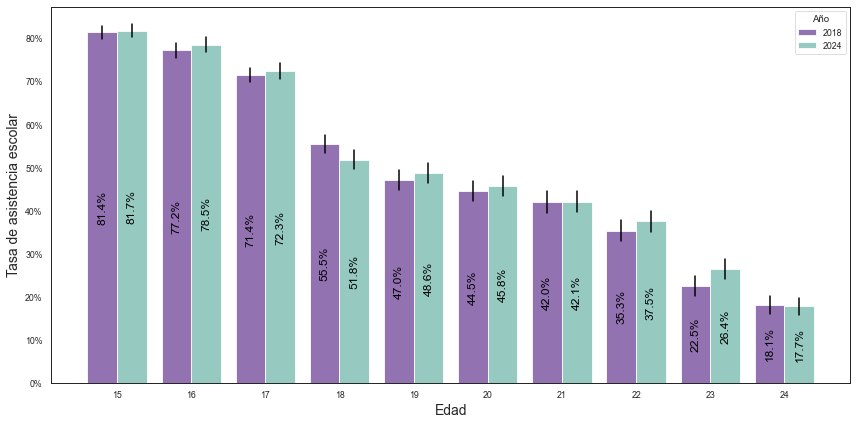

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
import pandas as pd

# === CARGAR DATOS ===
ruta = r"C:\Users\Jesus Sanchez\Desktop\ALEXIS\1. Estudio\Maestria BUAP - Economia\0. TESIS\Codigo\Tablas de Excel\Estadistica descriptiva.xlsx"
hoja = "Asis_esc por edades"

df = pd.read_excel(ruta, sheet_name=hoja, header=0)

# Limpiar nombres de columnas
df.columns = df.columns.str.strip()

# === CONFIGURACIÓN ESTÉTICA ===
sns.set(style="white", context="paper")
plt.figure(figsize=(12, 6))

# === GRAFICAR BARRAS ===
ax = sns.barplot(
    data=df,
    x="Edad",
    y="Media",
    hue="Anio",
    ci=None,
    palette= ["#9467bd", "#8dd3c7"]
)

# === AÑADIR LÍNEAS DE INTERVALO DE CONFIANZA ===
for i, row in df.iterrows():
    x_pos = list(df["Edad"].unique()).index(row["Edad"])
    offset = -0.2 if row["Anio"] == 2018 else 0.2
    ax.plot(
        [x_pos + offset, x_pos + offset],
        [row["Intervalo de confianza inferior"], row["Intervalo de confianza superior"]],
        color="black",
        linewidth=1.5
    )

# === AÑADIR ETIQUETAS DE PORCENTAJE (VERTICALES) ===
for patch in ax.patches:
    height = patch.get_height()
    if height > 0:  # 👈 Ignora las barras vacías
        x = patch.get_x() + patch.get_width() / 2
        y = height / 2
        ax.text(
            x,
            y,
            f"{height*100:.1f}%",
            ha="center",
            va="center",
            rotation=90,
            color="black",
            fontsize=12
        )

# === FORMATO Y ETIQUETAS ===
ax.yaxis.set_major_formatter(PercentFormatter(1))
plt.xlabel("Edad", fontsize=14)
plt.ylabel("Tasa de asistencia escolar", fontsize=14)
plt.legend(title="Año")
plt.tight_layout()
plt.show()


# Asistencia Escolar por Edades y Sexos


✅ Columnas detectadas y limpiadas:
 ['ano', 'sexo', 'edad', 'media', 'error_estandar_linealizado', 'intervalo_de_confianza_inferior', 'intervalo_de_confianza_superior']


C:\Users\Jesus Sanchez\AppData\Local\Temp\ipykernel_36580\3446525054.py:48: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\Jesus Sanchez\AppData\Local\Temp\ipykernel_36580\3446525054.py:48: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


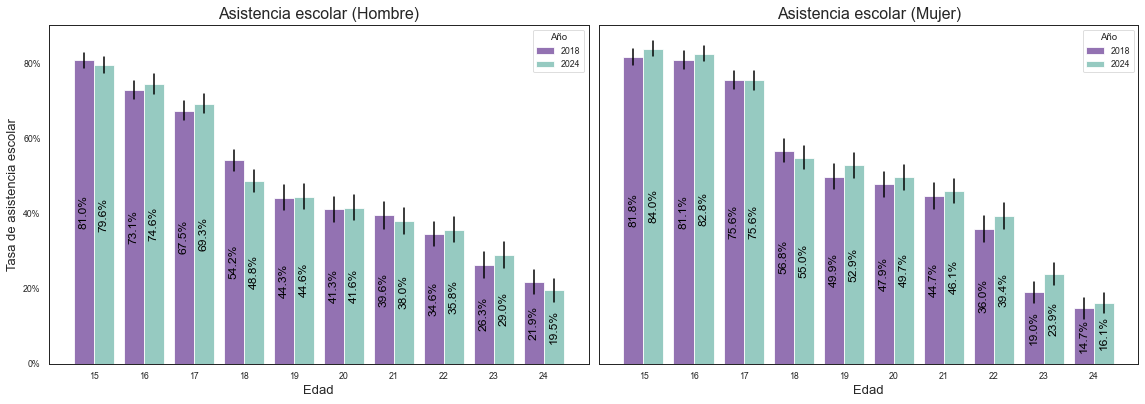

In [15]:
# ==== ASISTENCIA ESCOLAR POR SEXO Y AÑO ====
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
import pandas as pd
import unicodedata

# === CARGAR DATOS ===
ruta = r"C:\Users\Jesus Sanchez\Desktop\ALEXIS\1. Estudio\Maestria BUAP - Economia\0. TESIS\Codigo\Tablas de Excel\Estadistica descriptiva.xlsx"
hoja = "Asis_esc por edades y sexo"

df = pd.read_excel(ruta, sheet_name=hoja, header=0)

# === LIMPIAR NOMBRES DE COLUMNAS ===
def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(c for c in unicodedata.normalize("NFD", col) if unicodedata.category(c) != "Mn")
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

print("✅ Columnas detectadas y limpiadas:\n", df.columns.tolist())

# === RENOMBRAR A CLAVES ESTÁNDAR ===
renombres = {
    'ano': 'Anio',
    'año': 'Anio',
    'sexo': 'Sexo',
    'edad': 'Edad',
    'media': 'Media',
    'error_estandar_linealizado': 'Error',
    'intervalo_de_confianza_inferior': 'IC_inf',
    'intervalo_de_confianza_superior': 'IC_sup'
}
df = df.rename(columns={k: v for k, v in renombres.items() if k in df.columns})

# === CONFIGURACIÓN DE ESTILO ===
sns.set_theme(style="white", context="paper", palette="Set2")

# === CREAR FIGURA CON 2 SUBPLOTS (uno por sexo) ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sexos = ["Hombre", "Mujer"]

for ax, sexo in zip(axes, sexos):
    dff = df[df["Sexo"].str.lower().str.contains(sexo.lower())]

    sns.barplot(
        data=dff,
        x="Edad",
        y="Media",
        hue="Anio",
        ci=None,
        palette= ["#9467bd", "#8dd3c7"],
        ax=ax
    )

    # === Añadir intervalos de confianza ===
    for i, row in dff.iterrows():
        x_pos = list(dff["Edad"].unique()).index(row["Edad"])
        offset = -0.2 if int(row["Anio"]) == 2018 else 0.2
        ax.plot(
            [x_pos + offset, x_pos + offset],
            [row["IC_inf"], row["IC_sup"]],
            color="black",
            linewidth=1.5
        )

    # === Añadir etiquetas dentro de las barras ===
    for patch in ax.patches:
        height = patch.get_height()
        if height > 0:
            x = patch.get_x() + patch.get_width() / 2
            y = height / 2
            ax.text(
                x, y,
                f"{height*100:.1f}%",
                ha="center", va="center",
                rotation=90,
                color="black",
                fontsize=12
            )

    # === FORMATO ===
    ax.set_title(f"Asistencia escolar ({sexo})", fontsize=16)
    ax.set_xlabel("Edad", fontsize=13)
    ax.set_ylabel("Tasa de asistencia escolar" if sexo == "Hombre" else "", fontsize=13)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.legend(title="Año")

# === TÍTULO GENERAL ===
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
# ==============================
# PRUEBA DE DIFERENCIAS POR SEXO
# ==============================

import pandas as pd
import numpy as np
from scipy.stats import norm
import unicodedata

# === 1. Cargar datos ===
ruta = r"C:\Users\Jesus Sanchez\Desktop\ALEXIS\1. Estudio\Maestria BUAP - Economia\0. TESIS\Datos\Estadistica descriptiva con diseño de muestreo.xlsx"
hoja = "Distribucion por sexo errores"

df = pd.read_excel(ruta, sheet_name=hoja)

# === 2. Normalizar nombres de columnas ===
def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(c for c in unicodedata.normalize("NFD", col) if unicodedata.category(c) != "Mn")
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

# Intentar mapear columnas comunes
renombres = {
    "edad": "Edad",
    "ano": "Año",
    "año": "Año",
    "sexo": "Sexo",
    "asiste": "Asiste",
    "no_asiste": "No_asiste",
    "se": "Se"
}
df = df.rename(columns={k: v for k, v in renombres.items() if k in df.columns})

print("✅ Columnas detectadas:", df.columns.tolist())

# === 3. Calcular diferencias por edad y año ===
resultados = []

for (anio, edad), grupo in df.groupby(["Año", "Edad"]):

    # asegurar que hay dos sexos
    if len(grupo["Sexo"].unique()) < 2:
        continue

    # detectar formato de sexo
    if grupo["Sexo"].dtype == object:
        hombres = grupo[grupo["Sexo"].str.contains("hom", case=False, na=False)]
        mujeres = grupo[grupo["Sexo"].str.contains("muj", case=False, na=False)]
    else:
        hombres = grupo[grupo["Sexo"] == 1]
        mujeres = grupo[grupo["Sexo"] == 2]

    if len(hombres) == 0 or len(mujeres) == 0:
        continue

    ph = hombres["Asiste"].values[0]
    pm = mujeres["Asiste"].values[0]
    sh = hombres["Se"].values[0]
    sm = mujeres["Se"].values[0]

    # diferencia y estadísticos
    diff = ph - pm
    se_comb = np.sqrt(sh**2 + sm**2)
    z = diff / se_comb if se_comb > 0 else np.nan
    p_valor = 2 * (1 - norm.cdf(abs(z))) if not np.isnan(z) else np.nan

    # intervalos de confianza
    ci_low = diff - 1.96 * se_comb
    ci_high = diff + 1.96 * se_comb

    resultados.append({
        "Año": anio,
        "Edad": edad,
        "Asistencia Hombres": ph,
        "Asistencia Mujeres": pm,
        "Diferencia (H-M)": diff,
        "Error Estándar": se_comb,
        "Z": z,
        "Valor-p": p_valor,
        "IC95% inferior": ci_low,
        "IC95% superior": ci_high,
        "Decisión": "Rechazo H0" if (not np.isnan(p_valor) and p_valor < 0.05) else "No rechazo H0"
    })

res_df = pd.DataFrame(resultados)

# === 4. Formato de salida bonito ===
styled = (
    res_df.style
    .format({
        "Asistencia Hombres": "{:.2%}".format,
        "Asistencia Mujeres": "{:.2%}".format,
        "Diferencia (H-M)": "{:.2%}".format,
        "Error Estándar": "{:.3f}".format,
        "Z": "{:.2f}".format,
        "Valor-p": "{:.4f}".format,
        "IC95% inferior": "{:.2%}".format,
        "IC95% superior": "{:.2%}".format
    })
    .applymap(
        lambda x: "background-color: lightgreen; color: black" if x == "Rechazo H0" 
                  else ("background-color: salmon; color: black" if x == "No rechazo H0" else ""),
        subset=["Decisión"]
    )
    .background_gradient(subset=["Valor-p"], cmap="RdYlGn_r")
    .set_properties(**{
        "text-align": "center",
        "font-family": "Arial",
        "font-size": "11pt"
    })
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center"), 
                                     ("font-size", "11pt"),
                                     ("background-color", "#f2f2f2"),
                                     ("font-weight", "bold")]},
        {"selector": "td", "props": [("padding", "6px")]}
    ])
)

display(styled)

#GUARDAD TABLA DE INGRESOS DE ARRIBA 

import dataframe_image as dfi

dfi.export(styled, "tabla_tesis_proporciones_sexo.png", table_conversion="chrome")

✅ Columnas detectadas: ['Edad', 'No_asiste', 'Asiste', 'Sexo', 'Se', 'Año']


C:\Users\Jesus Sanchez\AppData\Local\Temp\ipykernel_36580\633928737.py:91: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  res_df.style


,Año,Edad,Asistencia Hombres,Asistencia Mujeres,Diferencia (H-M),Error Estándar,Z,Valor-p,IC95% inferior,IC95% superior,Decisión
0,2018,15,82.03%,82.16%,-0.13%,0.016,-0.08,0.9346,-3.23%,2.97%,No rechazo H0
1,2018,16,73.61%,81.08%,-7.47%,0.019,-4.00,0.0001,-11.13%,-3.81%,Rechazo H0
2,2018,17,67.02%,77.45%,-10.43%,0.019,-5.54,0.0000,-14.12%,-6.74%,Rechazo H0
3,2018,18,54.84%,58.97%,-4.13%,0.023,-1.82,0.0682,-8.57%,0.31%,No rechazo H0
4,2018,19,43.66%,54.12%,-10.46%,0.025,-4.14,0.0000,-15.41%,-5.51%,Rechazo H0
5,2018,20,41.13%,51.30%,-10.17%,0.026,-3.86,0.0001,-15.34%,-5.00%,Rechazo H0
6,2018,21,42.22%,51.67%,-9.45%,0.028,-3.37,0.0007,-14.94%,-3.96%,Rechazo H0
7,2018,22,35.60%,41.52%,-5.92%,0.028,-2.13,0.0332,-11.37%,-0.47%,Rechazo H0
8,2018,23,27.36%,25.23%,2.13%,0.028,0.77,0.4413,-3.29%,7.55%,No rechazo H0
9,2018,24,23.11%,20.66%,2.45%,0.028,0.88,0.3767,-2.98%,7.88%,No rechazo H0


In [22]:
import altair as alt

print("✅ Creando gráfico de hipótesis...")

# 1. Filtrar las filas "Total" que no queremos en este gráfico
#    Usamos .copy() para evitar advertencias de Pandas
res_df_filtrado = res_df[res_df['Edad'] != 'Total'].copy()

# 2. Asegurarse de que 'Edad' sea un tipo numérico para ordenar correctamente
try:
    res_df_filtrado['Edad'] = res_df_filtrado['Edad'].astype(int)
except ValueError:
    print("Advertencia: No se pudo convertir 'Edad' a entero. El orden puede ser alfabético.")
    pass # Dejarlo como objeto si falla la conversión

# 3. Definir el gráfico base con datos y codificaciones comunes
base = alt.Chart(res_df_filtrado).encode(
    # 'Edad:O' la trata como una categoría ordenada (Ordinal)
    y=alt.Y('Edad:O', title='Grupo de Edad', axis=alt.Axis(labelAngle=0)),
    
    # Colorear según la decisión, usando los colores de tu tabla
    color=alt.Color('Decisión', title='Decisión H0',
        scale=alt.Scale(
            domain=['Rechazo H0', 'No rechazo H0'],
            range=['#90EE90', '#FA8072'] # lightgreen y salmon
        )
    ),
    
    # Añadir tooltips para ver detalles al pasar el ratón
    tooltip=[
        alt.Tooltip('Año', title='Año'),
        alt.Tooltip('Edad', title='Edad'),
        alt.Tooltip('Diferencia (H-M)', title='Diferencia', format='.2%'),
        alt.Tooltip('IC95% inferior', title='IC 95% Inf.', format='.2%'),
        alt.Tooltip('IC95% superior', title='IC 95% Sup.', format='.2%'),
        alt.Tooltip('Valor-p', title='Valor-p', format='.4f'),
        alt.Tooltip('Decisión')
    ]
)

# 4. Capa de Intervalos de Confianza (las líneas de error)
error_bars = base.mark_rule(size=3).encode(
    # 'Diferencia (H-M)' y los IC son floats (ej. 0.05)
    # Usamos format='%' para que Altair los muestre como "5%"
    x=alt.X('IC95% inferior:Q', 
            title='Diferencia Asistencia (Hombres - Mujeres)',
            axis=alt.Axis(format='%')),
    x2='IC95% superior:Q'
)

# 5. Capa de Estimaciones Puntuales (los puntos)
points = base.mark_point(filled=True, size=100, opacity=1).encode(
    x=alt.X('Diferencia (H-M):Q')
)

# 6. Línea vertical en Cero (el valor de la hipótesis nula)
zero_line = alt.Chart().mark_rule(strokeDash=[5,5], color='black', strokeWidth=1).encode(
    x=alt.datum(0.0) # Dibuja la línea en x=0
)

# 7. Combinar las capas (barras + puntos + línea) y crear facetas por Año
final_chart = (error_bars + points + zero_line).facet(
    # Crea una columna separada para cada 'Año'
    column=alt.Column('Año:N', title='Año', 
                      header=alt.Header(titleOrient="bottom", labelOrient="bottom"))
).properties(
).interactive() # Permite hacer zoom y pan


# --- ¡AQUÍ ESTÁ LA MAGIA! ---
# Al tener la variable como última línea, el notebook la mostrará automáticamente.
final_chart

✅ Creando gráfico de hipótesis...


alt.FacetChart(...)

# Analisis Escolar por total de integrantes

C:\Users\Jesus Sanchez\AppData\Local\Temp\ipykernel_36580\1322327949.py:30: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Integrantes_num"] = df["Integrantes"].replace({"10 o mas": 10}).astype(int)


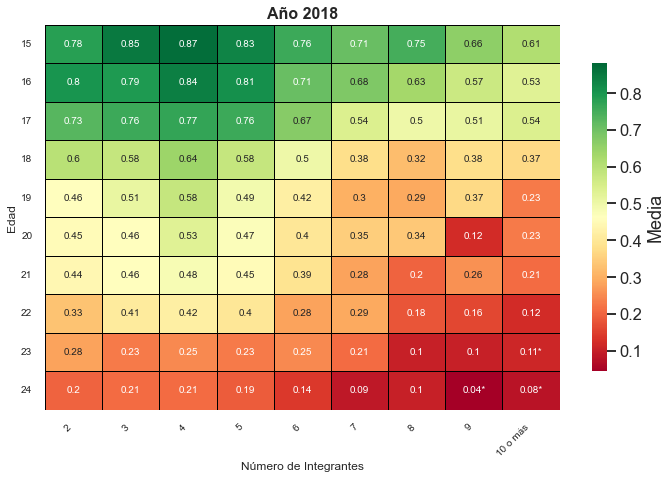

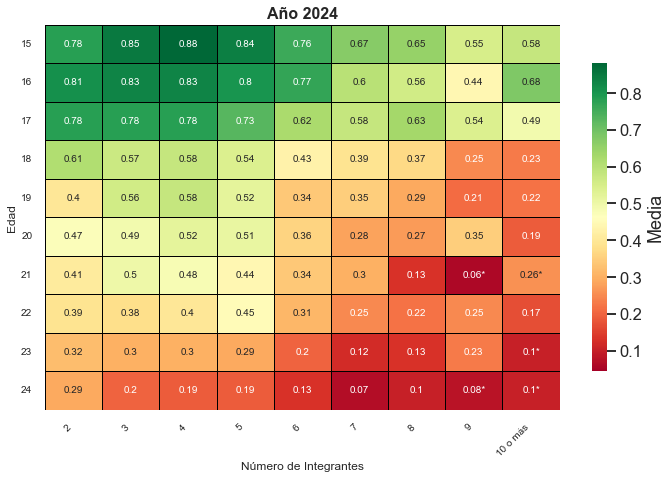

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import unicodedata

# === CARGAR DATOS ===
ruta = r"C:\Users\Jesus Sanchez\Desktop\ALEXIS\1. Estudio\Maestria BUAP - Economia\0. TESIS\Codigo\Tablas de Excel\Estadistica descriptiva.xlsx"
hoja = "Asis_esc por edades e integrant"
df = pd.read_excel(ruta, sheet_name=hoja, header=0)

# === LIMPIAR NOMBRES DE COLUMNAS ===
def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(c for c in unicodedata.normalize("NFD", col) if unicodedata.category(c) != "Mn")
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

# Renombrar columnas
df.rename(columns={
    "anio": "Anio",
    "integrantes": "Integrantes",
    "edad": "Edad",
    "media": "Media",
    "intervalo_de_confianza_inferior": "IC_inf",
    "intervalo_de_confianza_superior": "IC_sup"
}, inplace=True)

# Mapear columna 'Integrantes' a número
df["Integrantes_num"] = df["Integrantes"].replace({"10 o mas": 10}).astype(int)

col_nums = list(range(2,11))  # del 2 al 10
col_labels = [2,3,4,5,6,7,8,9,"10 o más"]

# Rango de color común
vmin = df["Media"].min()
vmax = df["Media"].max()

# Función para heatmap con asteriscos de no significancia
def plot_heatmap_significance(df, year):
    df_year = df[df["Anio"] == year]
    
    # Pivot de Media
    heatmap_data = df_year.pivot(index="Edad", columns="Integrantes_num", values="Media")
    heatmap_data = heatmap_data[[c for c in col_nums if c in heatmap_data.columns]].round(2)
    heatmap_data.rename(columns={10: "10 o más"}, inplace=True)
    
    # Crear DataFrame de anotaciones (mismo tamaño que heatmap)
    annot = heatmap_data.copy().astype(str)
    
    for edad in heatmap_data.index:
        for col in heatmap_data.columns:
            # Mapear columna de vuelta a número para verificar IC
            col_num = col if col != "10 o más" else 10
            # Buscar fila correspondiente
            fila = df_year[(df_year["Edad"]==edad) & (df_year["Integrantes_num"]==col_num)]
            if not fila.empty:
                ic_inf = fila["IC_inf"].values[0]
                ic_sup = fila["IC_sup"].values[0]
                # Si el intervalo incluye cero, agregar asterisco
                if ic_inf <= 0 <= ic_sup:
                    annot.loc[edad, col] += "*"

    # Crear figura
    plt.figure(figsize=(10,7))
    sns.heatmap(
        heatmap_data,
        annot=annot,
        fmt="",
        cmap="RdYlGn",
        vmin=vmin,
        vmax=vmax,
        linewidths=0.5,
        linecolor="black",
        annot_kws={"size":10},
        cbar_kws={'label':'Media', "shrink":0.8}
    )
    plt.title(f"Año {year}", fontsize=16, fontweight="bold")
    plt.xlabel("Número de Integrantes", fontsize=12)
    plt.ylabel("Edad", fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()

# Ejemplo
plot_heatmap_significance(df, 2018)
plot_heatmap_significance(df, 2024)


# Analisis Escolar por Ingreso

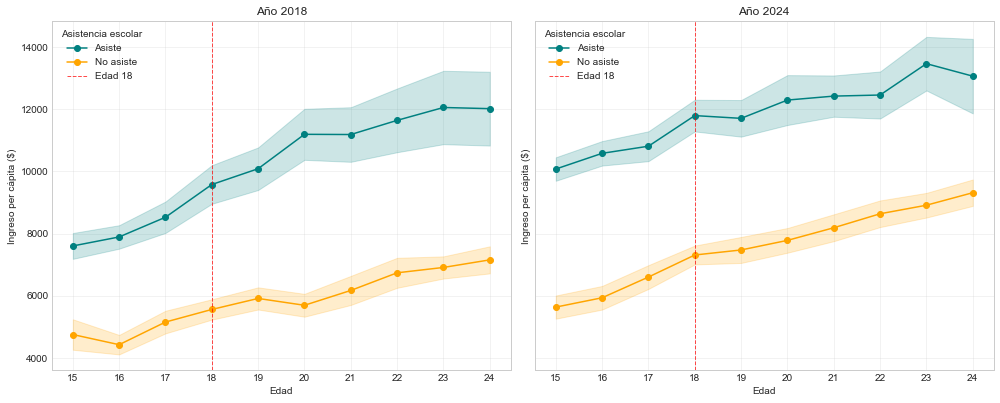

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np # Necesario para generar las marcas de 1 en 1

# =============================
# 1. Cargar archivo Excel
# =============================
ruta = r"C:\Users\Jesus Sanchez\Desktop\ALEXIS\1. Estudio\Maestria BUAP - Economia\0. TESIS\Codigo\Tablas de Excel\Estadistica descriptiva.xlsx"

df = pd.read_excel(ruta, sheet_name="Ingreso por asistencia y edad")

# =============================
# 2. Filtrar solo “No” en la columna de aportación
# =============================
df = df[df["Contando aportacion de jovenes"] == "No"]

# =============================
# 3. Limpieza básica
# =============================
cols_numericas = [
    "Media",
    "Error Estandar Linealizado",
    "Intervalo de confianza inferior",
    "Intervalo de confianza superior"
]

for c in cols_numericas:
    # Aseguramos que la columna sea numérica después de limpiar
    df[c] = df[c].replace(r"[\$,]", "", regex=True).astype(float)

# =============================
# 4. Función para graficar en un eje específico
# =============================
def plot_por_anio(df, anio, ax):
    df_anio = df[df["Anio"] == anio]

    for grupo, color in zip(["Asiste", "No asiste"], ["teal", "orange"]):
        df_g = df_anio[df_anio["Asistencia"] == grupo]

        # Línea principal (media)
        ax.plot(
            df_g["Edad"],
            df_g["Media"],
            label=f"{grupo}",
            color=color,
            marker="o"
        )

        # Banda de confianza (IC 95%)
        ax.fill_between(
            df_g["Edad"],
            df_g["Intervalo de confianza inferior"],
            df_g["Intervalo de confianza superior"],
            color=color,
            alpha=0.2
        )

    # Línea vertical en edad 18
    ax.axvline(x=18, color="red", linestyle="--", linewidth=1, alpha=0.7, label="Edad 18")

    # --- INSERCIÓN DEL CÓDIGO PARA FORZAR MARCAS EN EL EJE X DE 1 EN 1 ---
    # Calculamos el rango de edades para este subgráfico (este DataFrame ya está filtrado)
    min_edad = df_anio['Edad'].min()
    max_edad = df_anio['Edad'].max()
    marcas_x = np.arange(min_edad, max_edad + 1)
    
    # Aplicar las marcas al eje X del subplot actual (ax)
    ax.set_xticks(marcas_x)
    # ----------------------------------------------------------------------
    
    # Etiquetas y título
    ax.set_title(f"Año {anio}")
    ax.set_xlabel("Edad")
    ax.set_ylabel("Ingreso per cápita ($)")
    ax.grid(alpha=0.3)
    ax.legend(title="Asistencia escolar", loc="upper left")

# =============================
# 5. Crear figura con dos subplots
# =============================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

plot_por_anio(df, 2018, axes[0])
plot_por_anio(df, 2024, axes[1])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [30]:
# ======================================
# PRUEBA DE DIFERENCIAS – APORTACIÓN JÓVENES
# ======================================

import pandas as pd
import numpy as np
from scipy.stats import norm
import unicodedata

# === 1. Cargar datos ===
ruta = r"C:\Users\Jesus Sanchez\Desktop\ALEXIS\1. Estudio\Maestria BUAP - Economia\0. TESIS\Codigo\Tablas de Excel\Estadistica descriptiva.xlsx"
hoja = "Ingreso por asistencia y edad"

df = pd.read_excel(ruta, sheet_name=hoja)

# === 2. Normalizar nombres de columnas ===
def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(c for c in unicodedata.normalize("NFD", col) if unicodedata.category(c) != "Mn")
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

# Renombrar para facilitar el acceso
renombres = {
    "anio": "Anio",
    "año": "Anio",
    "edad": "Edad",
    "asistencia": "Asistencia",
    "contando_aportacion_de_jovenes": "Contando_aportacion_de_jovenes",
    "media": "Media",
    "error_estandar_linealizado": "Se"
}
df = df.rename(columns={k: v for k, v in renombres.items() if k in df.columns})

# === 3. Limpiar formato numérico de variables de ingreso ===
df["Media"] = df["Media"].replace(r"[\$,]", "", regex=True).astype(float)
df["Se"] = df["Se"].replace(r"[\$,]", "", regex=True).astype(float)

# === 4. Calcular diferencias entre "Sí" y "No" por edad, año y asistencia ===
resultados = []

for (anio, edad, asistencia), grupo in df.groupby(["Anio", "Edad", "Asistencia"]):

    if len(grupo["Contando_aportacion_de_jovenes"].unique()) < 2:
        continue  # debe haber ambos grupos

    grupo_si = grupo[grupo["Contando_aportacion_de_jovenes"].str.lower() == "si"]
    grupo_no = grupo[grupo["Contando_aportacion_de_jovenes"].str.lower() == "no"]

    if len(grupo_si) == 0 or len(grupo_no) == 0:
        continue

    media_si = grupo_si["Media"].values[0]
    media_no = grupo_no["Media"].values[0]
    se_si = grupo_si["Se"].values[0]
    se_no = grupo_no["Se"].values[0]

    diff = media_si - media_no
    se_comb = np.sqrt(se_si**2 + se_no**2)
    z = diff / se_comb if se_comb > 0 else np.nan
    p_valor = 2 * (1 - norm.cdf(abs(z))) if not np.isnan(z) else np.nan

    ci_low = diff - 1.96 * se_comb
    ci_high = diff + 1.96 * se_comb

    resultados.append({
        "Año": anio,
        "Edad": edad,
        "Asistencia": asistencia,
        "Media (Sí)": media_si,
        "Media (No)": media_no,
        "Diferencia (Sí - No)": diff,
        "Error Estándar": se_comb,
        "Z": z,
        "Valor-p": p_valor,
        "IC95% inferior": ci_low,
        "IC95% superior": ci_high,
        "Decisión": "Rechazo H0" if (not np.isnan(p_valor) and p_valor < 0.05) else "No rechazo H0"
    })

res_df = pd.DataFrame(resultados)

# === 5. Formato de salida bonito ===
import dataframe_image as dfi

styled = (
    res_df.style
    .format({
        "Media (Sí)": "${:,.2f}".format,
        "Media (No)": "${:,.2f}".format,
        "Diferencia (Sí - No)": "${:,.2f}".format,
        "Error Estándar": "{:.3f}".format,
        "Z": "{:.2f}".format,
        "Valor-p": "{:.4f}".format,
        "IC95% inferior": "${:,.2f}".format,
        "IC95% superior": "${:,.2f}".format
    })
    .applymap(
        lambda x: "background-color: lightgreen; color: black" if x == "Rechazo H0"
                  else ("background-color: salmon; color: black" if x == "No rechazo H0" else ""),
        subset=["Decisión"]
    )
    .background_gradient(subset=["Valor-p"], cmap="RdYlGn_r")
    .set_properties(**{
        "text-align": "center",
        "font-family": "Arial",
        "font-size": "11pt"
    })
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center"),
                                     ("font-size", "11pt"),
                                     ("background-color", "#f2f2f2"),
                                     ("font-weight", "bold")]},
        {"selector": "td", "props": [("padding", "6px")]}
    ])
)

display(styled)

# === 6. Guardar tabla como imagen ===
dfi.export(styled, "tabla_diferencias_aportacion_jovenes.png", table_conversion="chrome")
print("✅ Tabla exportada como 'tabla_diferencias_aportacion_jovenes.png'")


C:\Users\Jesus Sanchez\AppData\Local\Temp\ipykernel_21512\85547702.py:88: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  res_df.style


,Año,Edad,Asistencia,Media (Sí),Media (No),Diferencia (Sí - No),Error Estándar,Z,Valor-p,IC95% inferior,IC95% superior,Decisión
0,2018,15,Asiste,"$8,790.40","$7,603.11","$1,187.29",303.682,3.91,0.0001,$592.08,"$1,782.51",Rechazo H0
1,2018,15,No asiste,"$6,444.49","$4,751.84","$1,692.64",369.612,4.58,0.0000,$968.20,"$2,417.08",Rechazo H0
2,2018,16,Asiste,"$9,250.85","$7,892.63","$1,358.22",276.034,4.92,0.0000,$817.19,"$1,899.25",Rechazo H0
3,2018,16,No asiste,"$6,551.47","$4,424.79","$2,126.68",257.279,8.27,0.0000,"$1,622.41","$2,630.94",Rechazo H0
4,2018,17,Asiste,"$9,822.31","$8,527.01","$1,295.30",366.109,3.54,0.0004,$577.73,"$2,012.88",Rechazo H0
5,2018,17,No asiste,"$7,690.55","$5,152.89","$2,537.65",297.896,8.52,0.0000,"$1,953.78","$3,121.53",Rechazo H0
6,2018,18,Asiste,"$11,159.95","$9,580.30","$1,579.65",447.845,3.53,0.0004,$701.87,"$2,457.42",Rechazo H0
7,2018,18,No asiste,"$7,986.49","$5,558.69","$2,427.81",245.631,9.88,0.0000,"$1,946.37","$2,909.24",Rechazo H0
8,2018,19,Asiste,"$11,958.80","$10,089.38","$1,869.42",506.481,3.69,0.0002,$876.72,"$2,862.12",Rechazo H0
9,2018,19,No asiste,"$8,873.90","$5,913.32","$2,960.58",279.636,10.59,0.0000,"$2,412.49","$3,508.66",Rechazo H0


✅ Tabla exportada como 'tabla_diferencias_aportacion_jovenes.png'


In [33]:
# ======================================
# GRÁFICO DE DIFERENCIAS – APORTACIÓN JÓVENES (con línea H0 y resaltado)
# ======================================

import altair as alt

print("✅ Creando gráfico con línea de hipótesis nula y resaltado de Rechazo H₀...")

# 1. Asegurarse de que Edad sea numérica
res_df_filtrado = res_df.copy()
try:
    res_df_filtrado["Edad"] = res_df_filtrado["Edad"].astype(int)
except:
    pass

# 2. Gráfico base
base = alt.Chart(res_df_filtrado).encode(
    y=alt.Y('Edad:O', title='Edad', axis=alt.Axis(labelAngle=0)),
    color=alt.Color('Decisión', title='Decisión H₀',
        scale=alt.Scale(
            domain=['Rechazo H0', 'No rechazo H0'],
            range=['#4CAF50', '#FA8072']  # Verde y salmón
        )
    ),
    tooltip=[
        alt.Tooltip('Año', title='Año'),
        alt.Tooltip('Asistencia', title='Asistencia escolar'),
        alt.Tooltip('Edad', title='Edad'),
        alt.Tooltip('Diferencia (Sí - No)', title='Diferencia (Sí - No)', format='$,.2f'),
        alt.Tooltip('IC95% inferior', title='IC 95% Inf.', format='$,.2f'),
        alt.Tooltip('IC95% superior', title='IC 95% Sup.', format='$,.2f'),
        alt.Tooltip('Valor-p', title='Valor-p', format='.4f'),
        alt.Tooltip('Decisión', title='Decisión H₀')
    ]
)

# 3. Barras de error (intervalos de confianza)
error_bars = base.mark_rule(size=3).encode(
    x=alt.X('IC95% inferior:Q', 
            title='Diferencia de medias (Sí - No)',
            axis=alt.Axis(format='$,.0f')),
    x2='IC95% superior:Q'
)

# 4. Puntos (estimaciones puntuales)
#    Usamos shape distinto y borde negro para los casos donde se rechaza H0
points = base.mark_point(size=120, filled=True, stroke='black', strokeWidth=1.5).encode(
    x=alt.X('Diferencia (Sí - No):Q'),
    shape=alt.Shape('Decisión', 
                    scale=alt.Scale(domain=['Rechazo H0', 'No rechazo H0'],
                                    range=['triangle-up', 'circle']),
                    legend=alt.Legend(title='Decisión H₀'))
)

# 5. Línea vertical en cero (hipótesis nula)
zero_line = alt.Chart(pd.DataFrame({'x': [0]})).mark_rule(
    color='black',
    strokeDash=[5,5],
    size=2
).encode(x='x')

# 6. Combinar capas y facetear por año y asistencia
final_chart = (error_bars + points + zero_line).facet(
    column=alt.Column('Año:N', title='Año'),
    row=alt.Row('Asistencia:N', title='Asistencia escolar')
).properties(
    background='#FFFFFF'
).configure_title(
    fontSize=14,
    anchor='middle'
).interactive()

final_chart


✅ Creando gráfico con línea de hipótesis nula y resaltado de Rechazo H₀...


alt.FacetChart(...)

# Salario por nivel educativo 25-65 años

Generando gráfico para el año 2018...


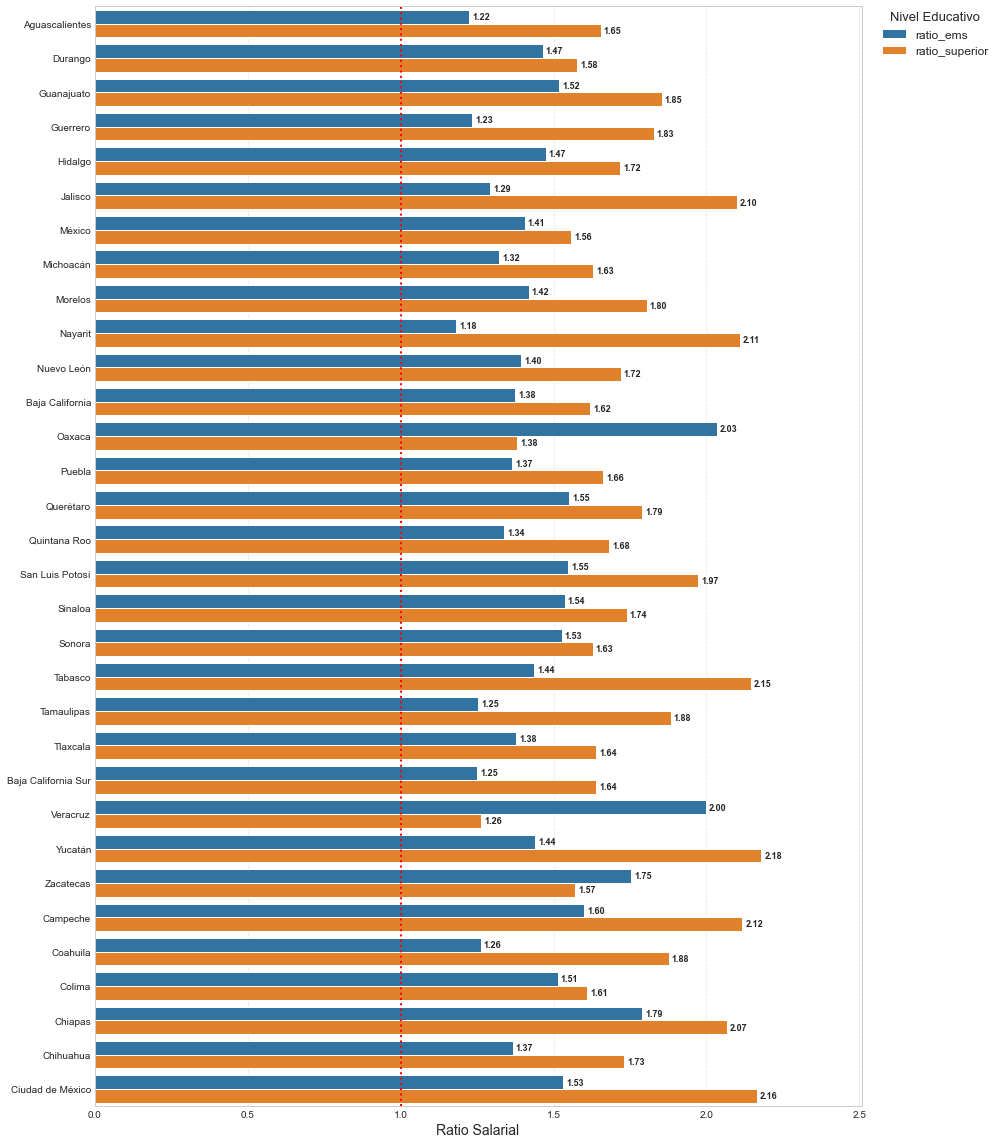

--- Fin del gráfico 2018 ---

Generando gráfico para el año 2024...


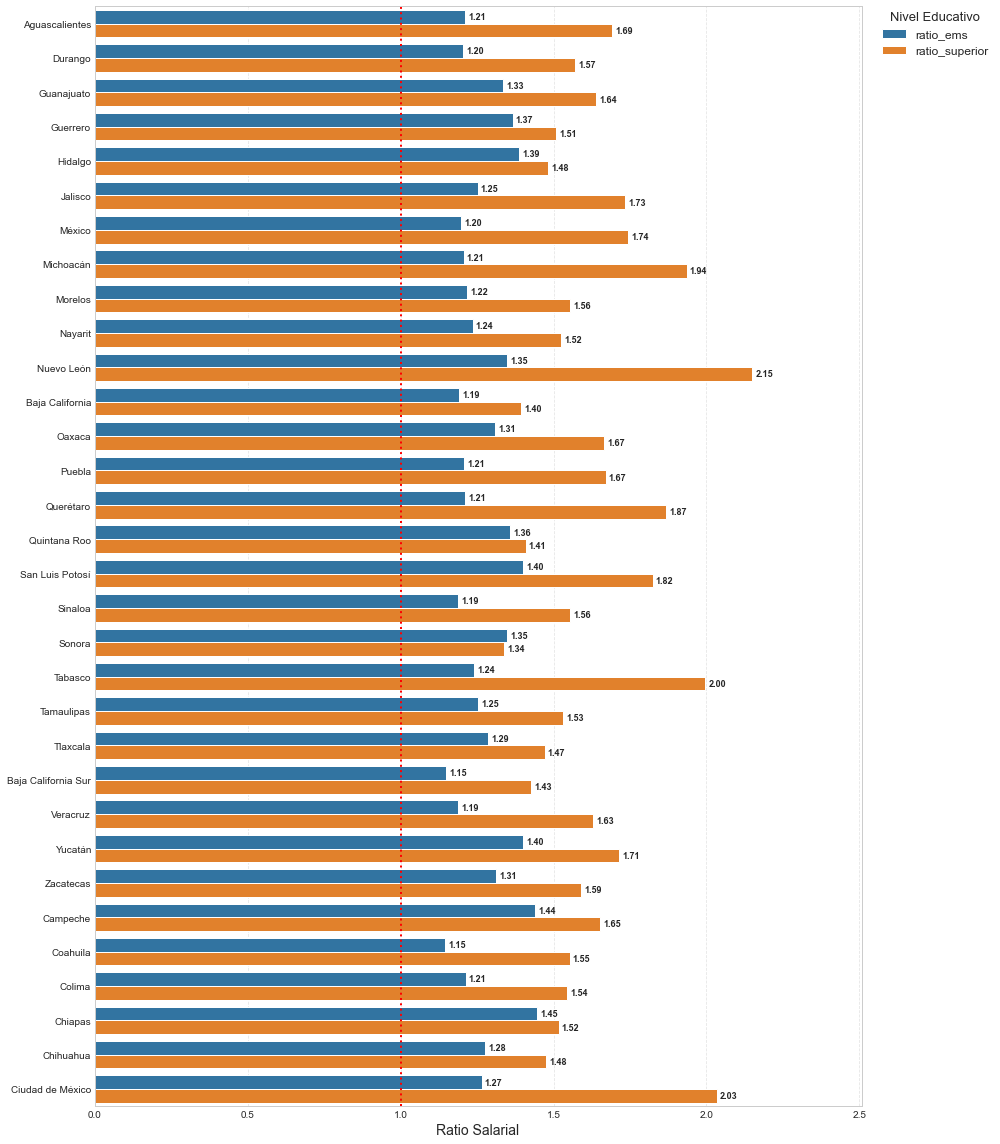

--- Fin del gráfico 2024 ---



In [83]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. CARGA Y PREPARACIÓN ---
ruta = r"C:\Users\Jesus Sanchez\Desktop\ALEXIS\1. Estudio\Maestria BUAP - Economia\0. TESIS\Codigo\ratios_salariales_estatales.csv"

try:
    df = pd.read_csv(ruta)
    df.columns = df.columns.str.strip()
    
    estados_inegi = {
        1: 'Aguascalientes', 2: 'Baja California', 3: 'Baja California Sur', 4: 'Campeche',
        5: 'Coahuila', 6: 'Colima', 7: 'Chiapas', 8: 'Chihuahua', 9: 'Ciudad de México',
        10: 'Durango', 11: 'Guanajuato', 12: 'Guerrero', 13: 'Hidalgo', 14: 'Jalisco',
        15: 'México', 16: 'Michoacán', 17: 'Morelos', 18: 'Nayarit', 19: 'Nuevo León',
        20: 'Oaxaca', 21: 'Puebla', 22: 'Querétaro', 23: 'Quintana Roo', 24: 'San Luis Potosí',
        25: 'Sinaloa', 26: 'Sonora', 27: 'Tabasco', 28: 'Tamaulipas', 29: 'Tlaxcala',
        30: 'Veracruz', 31: 'Yucatán', 32: 'Zacatecas'
    }
    df['Nombre_Entidad'] = df['entidad'].map(estados_inegi)

    cols_ratios = ['ratio_ems', 'ratio_superior']
    
    # Calculamos el máximo global para que ambas gráficas tengan la misma escala (Importante para comparar)
    max_valor_global = df[cols_ratios].max().max()

    # --- 2. BUCLE PARA GENERAR AMBOS AÑOS ---
    anios_a_graficar = [2018, 2024]

    for anio in anios_a_graficar:
        print(f"Generando gráfico para el año {anio}...")
        
        # Filtrar y Derretir (Melt)
        df_anio = df[df['anio'] == anio].copy()
        
        df_melted = df_anio.melt(
            id_vars=['Nombre_Entidad'], 
            value_vars=cols_ratios,
            var_name='Nivel Educativo', 
            value_name='Ratio Salarial'
        )

        # Configuración del Gráfico
        plt.figure(figsize=(14, 16))
        
        ax = sns.barplot(
            data=df_melted,
            x='Ratio Salarial',
            y='Nombre_Entidad',
            hue='Nivel Educativo',
            palette='tab10'
        )

        ax.axvline(x=1, color='red', linestyle=':', linewidth=2)

        # Agregar etiquetas numéricas
        for container in ax.containers:
            ax.bar_label(
                container, 
                fmt='%.2f',      
                padding=3,       
                fontsize=9,      
                fontweight='bold' 
            )

        # Títulos y ejes
        #plt.title(f'Ratios Salariales por Entidad Federativa ({anio})', fontsize=18)
        plt.xlabel('Ratio Salarial', fontsize=14)
        plt.ylabel('') 
        
        # FIJAR ESCALA COMÚN (Truco para Tesis)
        plt.xlim(0, max_valor_global * 1.15) 
        
        plt.grid(axis='x', linestyle='--', alpha=0.5)

        # Leyenda afuera
        plt.legend(
            title='Nivel Educativo', 
            bbox_to_anchor=(1.02, 1), 
            loc='upper left',         
            borderaxespad=0,          
            fontsize=12,
            title_fontsize=13
        )

        plt.tight_layout()
        
        # Mostrar gráfico
        plt.show()
        
        print(f"--- Fin del gráfico {anio} ---\n")

except Exception as e:
    print(f"Error: {e}")

# Acceso a internet 

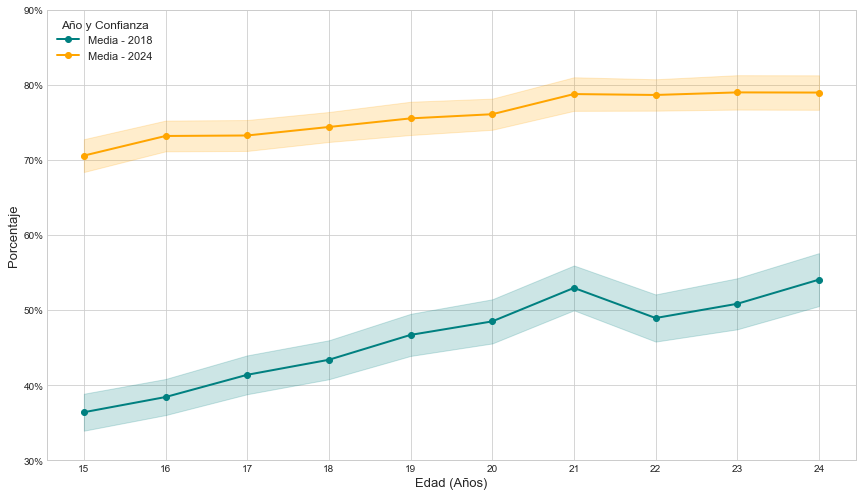

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
import numpy as np
from matplotlib.ticker import PercentFormatter



# === CARGAR DATOS ===
ruta = r"C:\Users\Jesus Sanchez\Desktop\ALEXIS\1. Estudio\Maestria BUAP - Economia\0. TESIS\Codigo\Tablas de Excel\Estadistica descriptiva.xlsx"
hoja = "Internet"
df = pd.read_excel(ruta, sheet_name=hoja, header=0)

# === LIMPIAR NOMBRES DE COLUMNAS ===
def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(c for c in unicodedata.normalize("NFD", col) if unicodedata.category(c) != "Mn")
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

# Renombrar columnas
df.rename(columns={
    "anio": "Anio",
    "edad": "Edad",
    "media": "Media",
    "intervalo_de_confianza_inferior": "IC_inf",
    "intervalo_de_confianza_superior": "IC_sup"
}, inplace=True)

# Convertir la columna 'Anio' a string para usarla como categoría (hue)
df['Anio'] = df['Anio'].astype(str)

# --- CONFIGURACIÓN DEL GRÁFICO ---
plt.figure(figsize=(12, 7))
plt.style.use('seaborn-v0_8-whitegrid') # Estilo limpio

# Definir colores para cada año
colores = {
    '2018': 'teal',    # Color del primer subplot
    '2024': 'orange'   # Color del segundo subplot
}

## 📊 Gráfico de Líneas con Bandas de Confianza por Año

# 1. Dibujar las Bandas de Confianza (IC 95%) y la Línea de la Media para cada año

for anio, color in colores.items():
    df_anio = df[df['Anio'] == anio]

    # Banda de confianza (IC 95%)
    plt.fill_between(
        df_anio["Edad"],
        df_anio["IC_inf"],
        df_anio["IC_sup"],
        color=color,
        alpha=0.2,
        label=f"IC 95% - {anio}" # Etiqueta para la leyenda de las bandas
    )
    
    # Línea principal (media)
    plt.plot(
        df_anio["Edad"],
        df_anio["Media"],
        label=f"Media - {anio}", # Etiqueta para la leyenda de las líneas
        color=color,
        marker="o",
        linewidth=2
    )

# 2. Configuración general del gráfico

# --- INSERCIÓN DEL CÓDIGO PARA FORZAR MARCAS EN EL EJE X DE 1 EN 1 ---
min_edad = df['Edad'].min()
max_edad = df['Edad'].max()
marcas_x = np.arange(min_edad, max_edad + 1)
plt.xticks(marcas_x)
# ----------------------------------------------------------------------

# Configuración y etiquetas
#plt.title('Media del Indicador por Edad y Año con Bandas de Confianza del 95%', 
#          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Edad (Años)', fontsize=13)
plt.ylabel('Porcentaje', fontsize=13)

# Ajustar límites del eje Y para una mejor visualización
plt.ylim(0.3, 0.9) 

# Crear una leyenda más clara que combine líneas y bandas
# Para evitar duplicar las etiquetas en la leyenda, se ajusta manualmente.
handles, labels = plt.gca().get_legend_handles_labels()

# Diccionario para agrupar las etiquetas: queremos una sola entrada por año.
unique_labels = {}
for h, l in zip(handles, labels):
    # La etiqueta de la línea es la que queremos usar: 'Media - 2018', 'Media - 2024'
    if 'Media' in l:
        unique_labels[l] = h

# Agregar las etiquetas de las bandas de forma manual (opcional, si quieres las 4 entradas)
# unique_labels['IC 95% - 2018'] = handles[0] # Handle de la primera banda
# unique_labels['IC 95% - 2024'] = handles[1] # Handle de la segunda banda

plt.legend(unique_labels.values(), unique_labels.keys(), 
           title='Año y Confianza', loc='upper left', fontsize=11, title_fontsize=12)

plt.tight_layout() # Ajusta el diseño para que todo quepa
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.show()

# Horas dedicadas al no estudio

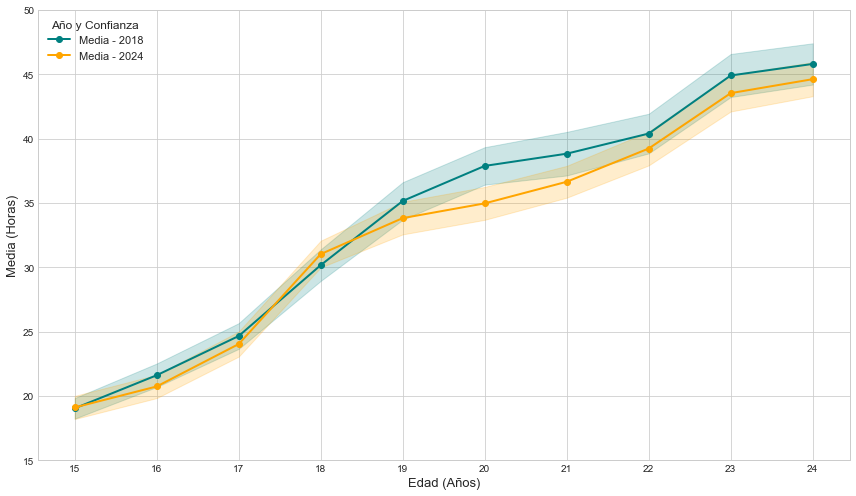

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
import numpy as np # Importado para forzar las marcas del eje X

# === CARGAR DATOS ===
ruta = r"C:\Users\Jesus Sanchez\Desktop\ALEXIS\1. Estudio\Maestria BUAP - Economia\0. TESIS\Codigo\Tablas de Excel\Estadistica descriptiva.xlsx"
hoja = "Horas"
df = pd.read_excel(ruta, sheet_name=hoja, header=0)

# === LIMPIAR NOMBRES DE COLUMNAS ===
def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(c for c in unicodedata.normalize("NFD", col) if unicodedata.category(c) != "Mn")
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

# Renombrar columnas
df.rename(columns={
    "anio": "Anio",
    "edad": "Edad",
    "media": "Media",
    "intervalo_de_confianza_inferior": "IC_inf",
    "intervalo_de_confianza_superior": "IC_sup"
}, inplace=True)

# Convertir la columna 'Anio' a string para usarla como categoría (hue)
df['Anio'] = df['Anio'].astype(str)
# NOTA: Se convierte 'Edad' a numérica para los cálculos y ploteo continuo
df['Edad'] = pd.to_numeric(df['Edad']) 

# --- CONFIGURACIÓN DEL GRÁFICO ---
plt.figure(figsize=(12, 7))
plt.style.use('seaborn-v0_8-whitegrid') # Estilo limpio

# Definir colores replicando el diseño solicitado
colores = {
    '2018': 'teal',    # Color del primer diseño
    '2024': 'orange'   # Color del primer diseño
}

## 📊 Gráfico de Líneas con Bandas de Confianza por Año

# 1. Dibujar las Bandas de Confianza (IC 95%) y la Línea de la Media para cada año

for anio, color in colores.items():
    df_anio = df[df['Anio'] == anio]

    # Banda de confianza (IC 95%)
    plt.fill_between(
        df_anio["Edad"],
        df_anio["IC_inf"],
        df_anio["IC_sup"],
        color=color,
        alpha=0.2,
        label=f"IC 95% - {anio}" # Etiqueta para la leyenda de las bandas
    )
    
    # Línea principal (media)
    plt.plot(
        df_anio["Edad"],
        df_anio["Media"],
        label=f"Media - {anio}", # Etiqueta para la leyenda de las líneas
        color=color,
        marker="o",
        linewidth=2
    )

# 2. Configuración general del gráfico

# --- CÓDIGO PARA FORZAR MARCAS EN EL EJE X DE 1 EN 1 ---
min_edad = df['Edad'].min()
max_edad = df['Edad'].max()
marcas_x = np.arange(min_edad, max_edad + 1)
plt.xticks(marcas_x)
# --------------------------------------------------------

# Configuración y etiquetas
#plt.title('Media de Horas por Edad y Año con Bandas de Confianza del 95%', 
#          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Edad (Años)', fontsize=13)
plt.ylabel('Media (Horas)', fontsize=13) # Etiqueta del eje Y de la gráfica original de Horas

# Ajustar límites del eje Y para una mejor visualización
plt.ylim(15, 50) # Límites del eje Y de la gráfica original de Horas

# Crear una leyenda más clara que combine líneas y bandas
# Se mantiene la lógica para mostrar solo las entradas de "Media"
handles, labels = plt.gca().get_legend_handles_labels()
unique_labels = {}
for h, l in zip(handles, labels):
    if 'Media' in l:
        unique_labels[l] = h

plt.legend(unique_labels.values(), unique_labels.keys(), 
           title='Año y Confianza', loc='upper left', fontsize=11, title_fontsize=12)

plt.tight_layout() # Ajusta el diseño para que todo quepa
plt.show()

# Asistencia por Region


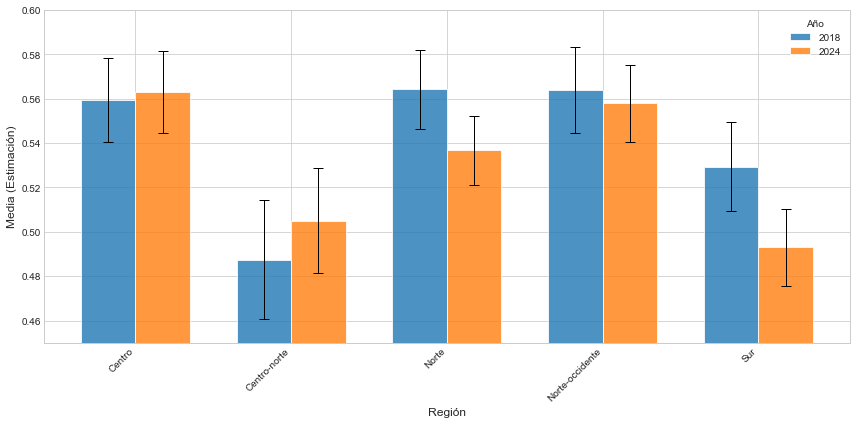

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
import numpy as np # Importado para forzar las marcas del eje X

# === CARGAR DATOS ===
ruta = r"C:\Users\Jesus Sanchez\Desktop\ALEXIS\1. Estudio\Maestria BUAP - Economia\0. TESIS\Codigo\Tablas de Excel\Estadistica descriptiva.xlsx"
hoja = "Region"
df = pd.read_excel(ruta, sheet_name=hoja, header=0)

# === LIMPIAR NOMBRES DE COLUMNAS ===
def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(c for c in unicodedata.normalize("NFD", col) if unicodedata.category(c) != "Mn")
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

# Renombrar columnas
df.rename(columns={
    "anio": "Anio",
    "region": "Region",
    "media": "Media",
    "intervalo_de_confianza_inferior": "IC_inf",
    "intervalo_de_confianza_superior": "IC_sup"
}, inplace=True)

# Convertir la columna 'Anio' a string para usarla como categoría (hue)
df['Anio'] = df['Anio'].astype(str)

# === GENERACIÓN DEL GRÁFICO ===

# 1. Calcular la diferencia entre la media y los límites del intervalo de confianza
# El error inferior es Media - IC_inf
df['yerr_inf'] = df['Media'] - df['IC_inf']
# El error superior es IC_sup - Media
df['yerr_sup'] = df['IC_sup'] - df['Media']

# Combinar los errores superior e inferior en un array de 2xN para Matplotlib
# Matplotlib espera [[error_inf_1, error_inf_2, ...], [error_sup_1, error_sup_2, ...]]
yerr = np.array([df['yerr_inf'].values, df['yerr_sup'].values])

# 2. Definir el ancho de las barras y las posiciones
bar_width = 0.35
# Obtener las regiones únicas para usarlas como etiquetas del eje X
regions = df['Region'].unique()
# Posiciones base para el eje X
x_base = np.arange(len(regions))

# 3. Separar los datos por año
df_2018 = df[df['Anio'] == '2018'].sort_values('Region')
df_2024 = df[df['Anio'] == '2024'].sort_values('Region')

# Asegúrate de que el orden de las regiones sea el mismo en ambos DataFrames
# y que el orden de yerr para cada año coincida con el orden de las Medias
yerr_2018 = np.array([df_2018['yerr_inf'].values, df_2018['yerr_sup'].values])
yerr_2024 = np.array([df_2024['yerr_inf'].values, df_2024['yerr_sup'].values])


# 4. Crear la figura y los ejes
plt.style.use('seaborn-v0_8-whitegrid') # Estilo para un fondo más limpio
fig, ax = plt.subplots(figsize=(12, 6))

# 5. Dibujar las barras para 2018
rects1 = ax.bar(
    x_base - bar_width/2, # Desplazar la barra de 2018 a la izquierda
    df_2018['Media'],
    bar_width,
    label='2018',
    yerr=yerr_2018, # Barras de error para el IC
    capsize=5, # Tamaño de las tapas de las barras de error
    color='#1f77b4', # Color por defecto de matplotlib (azul)
    alpha=0.8,
    error_kw={'ecolor': 'black', 'lw': 1, 'capthick': 1} # Estilo de las barras de error
)

# 6. Dibujar las barras para 2024
rects2 = ax.bar(
    x_base + bar_width/2, # Desplazar la barra de 2024 a la derecha
    df_2024['Media'],
    bar_width,
    label='2024',
    yerr=yerr_2024, # Barras de error para el IC
    capsize=5,
    color='#ff7f0e', # Color por defecto de matplotlib (naranja)
    alpha=0.8,
    error_kw={'ecolor': 'black', 'lw': 1, 'capthick': 1}
)

# 7. Configuración del gráfico
# Título y etiquetas
#ax.set_title('Media Regional por Año con Intervalo de Confianza del 95%', fontsize=16)
ax.set_ylabel('Media (Estimación)', fontsize=12)
ax.set_xlabel('Región', fontsize=12)

# Marcas y etiquetas del eje X
ax.set_xticks(x_base)
ax.set_xticklabels(regions, rotation=45, ha="right") # Rotar etiquetas para mejor lectura

# Leyenda
ax.legend(title='Año')

# Líneas de referencia para una lectura más fácil (opcional, ya cubierto por el estilo whitegrid)
# ax.grid(axis='y', linestyle='--', alpha=0.7)

# Límites del eje Y (ajustar si es necesario)
# En el ejemplo el rango de Medias va de ~0.47 a ~0.59, por lo que 0.45 a 0.6 es un buen rango.
ax.set_ylim(0.45, 0.60) 

# Añadir las etiquetas de la Media en la parte superior de las barras (opcional)
def autolabel(rects, df_data):
    for i, rect in enumerate(rects):
        height = rect.get_height()
        # Usa el valor de la columna 'Media' del DataFrame
        ax.annotate(
            f'{height:.3f}', # Formato con 3 decimales
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),  # 3 puntos de offset vertical
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=9
        )

# autolabel(rects1, df_2018)
# autolabel(rects2, df_2024)


# Mostrar el gráfico
plt.tight_layout() # Ajustar el diseño para que las etiquetas no se corten
plt.show()

# Asistencia por trabajo

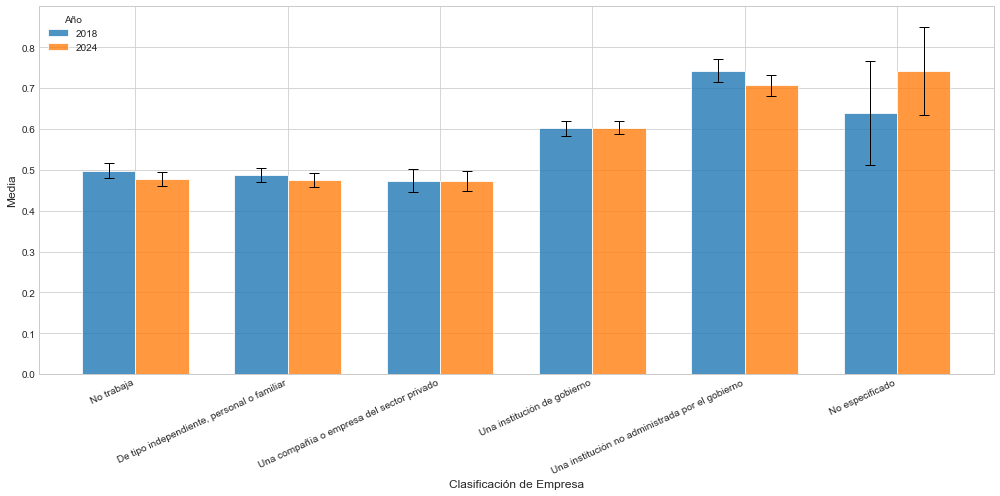

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
import numpy as np # Importado para forzar las marcas del eje X

# === CARGAR DATOS ===
ruta = r"C:\Users\Jesus Sanchez\Desktop\ALEXIS\1. Estudio\Maestria BUAP - Economia\0. TESIS\Codigo\Tablas de Excel\Estadistica descriptiva.xlsx"
hoja = "Trabajos"
df = pd.read_excel(ruta, sheet_name=hoja, header=0)

# === LIMPIAR NOMBRES DE COLUMNAS ===
def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(c for c in unicodedata.normalize("NFD", col) if unicodedata.category(c) != "Mn")
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

# Renombrar columnas
df.rename(columns={
    "anio": "Anio",
    "clasificacion_empresa": "Clasificacion_empresa",
    "media": "Media",
    "intervalo_de_confianza_inferior": "IC_inf",
    "intervalo_de_confianza_superior": "IC_sup"
}, inplace=True)

# Convertir la columna 'Anio' a string para usarla como categoría (hue)
df['Anio'] = df['Anio'].astype(str)

# 1. Calcular la diferencia entre la media y los límites del intervalo de confianza
df['yerr_inf'] = df['Media'] - df['IC_inf'] # Error inferior es Media - IC_inf
df['yerr_sup'] = df['IC_sup'] - df['Media'] # Error superior es IC_sup - Media

# 2. Definir el ancho de las barras y las posiciones
bar_width = 0.35
# Obtener las categorías únicas para las etiquetas del eje X
categorias = df['Clasificacion_empresa'].unique()
# Posiciones base para el eje X
x_base = np.arange(len(categorias))

# 3. Separar los datos por año
# Es crucial ordenar por la columna de la categoría para asegurar que los índices de x_base,
# Media y yerr coincidan.
df_2018 = df[df['Anio'] == '2018'].sort_values('Clasificacion_empresa')
df_2024 = df[df['Anio'] == '2024'].sort_values('Clasificacion_empresa')

# 4. Crear los arrays de error para Matplotlib
yerr_2018 = np.array([df_2018['yerr_inf'].values, df_2018['yerr_sup'].values])
yerr_2024 = np.array([df_2024['yerr_inf'].values, df_2024['yerr_sup'].values])


# === GENERACIÓN DEL GRÁFICO ===

# 1. Crear la figura y los ejes
#plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 7)) # Aumentar el tamaño horizontal para las etiquetas

# 2. Dibujar las barras para 2018
rects1 = ax.bar(
    x_base - bar_width/2, # Desplazar la barra de 2018 a la izquierda
    df_2018['Media'],
    bar_width,
    label='2018',
    yerr=yerr_2018, # Barras de error para el IC
    capsize=5,
    color='#1f77b4', # Azul
    alpha=0.8,
    error_kw={'ecolor': 'black', 'lw': 1, 'capthick': 1}
)

# 3. Dibujar las barras para 2024
rects2 = ax.bar(
    x_base + bar_width/2, # Desplazar la barra de 2024 a la derecha
    df_2024['Media'],
    bar_width,
    label='2024',
    yerr=yerr_2024, # Barras de error para el IC
    capsize=5,
    color='#ff7f0e', # Naranja
    alpha=0.8,
    error_kw={'ecolor': 'black', 'lw': 1, 'capthick': 1}
)

# 4. Configuración del gráfico
# Título y etiquetas
#ax.set_title('Media por Clasificación de Empresa y Año (IC 95%)', fontsize=16)
ax.set_ylabel('Media', fontsize=12)
ax.set_xlabel('Clasificación de Empresa', fontsize=12)

# Marcas y etiquetas del eje X
ax.set_xticks(x_base)
# Usar las categorías para las etiquetas, rotadas para mejor lectura
ax.set_xticklabels(categorias, rotation=25, ha="right", fontsize=10) 

# Leyenda
ax.legend(title='Año', loc='upper left')

# Límites del eje Y: El rango de Medias va de ~0.47 a ~0.74, o hasta 0.85 con el error
# Se usa un rango que muestre los datos claramente.
y_min = min(df['IC_inf'].min() - 0.05, 0)
y_max = df['IC_sup'].max() + 0.05
ax.set_ylim(y_min, y_max) 

# Función para añadir las etiquetas de la Media en la parte superior de las barras
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f'{height:.3f}',
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3), 
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=8 # Tamaño de fuente reducido
        )

# Añadir las etiquetas de la Media
#autolabel(rects1)
#autolabel(rects2)


# Mostrar el gráfico
plt.tight_layout()
plt.show()


# Razones para no asistir al escuela

C:\Users\Jesus Sanchez\AppData\Local\Temp\ipykernel_25824\372953640.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('GnBu') # Puedes cambiar 'GnBu' por 'Blues', 'Teal' o 'viridis'


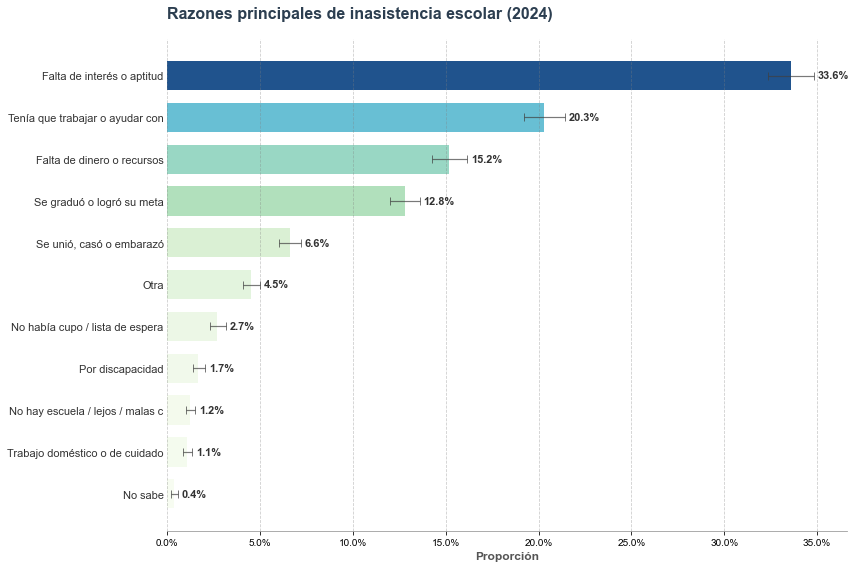

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
import numpy as np
from matplotlib.ticker import PercentFormatter
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# === 1. CARGAR DATOS ===
ruta = r"C:\Users\Jesus Sanchez\Desktop\ALEXIS\1. Estudio\Maestria BUAP - Economia\0. TESIS\Codigo\Tablas de Excel\Estadistica descriptiva.xlsx"
hoja = "No asistencia escolar"
df = pd.read_excel(ruta, sheet_name=hoja, header=0)

# === 2. LIMPIEZA DE DATOS (Tu lógica original) ===
def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(c for c in unicodedata.normalize("NFD", col) if unicodedata.category(c) != "Mn")
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

# Renombrar columnas
df.rename(columns={
    "anio": "Anio",
    "razon": "Razon",
    "media": "Media",
    "intervalo_de_confianza_inferior": "IC_inf",
    "intervalo_de_confianza_superior": "IC_sup"
}, inplace=True)

df['Anio'] = df['Anio'].astype(str)

# === 3. PREPARACIÓN PARA EL GRÁFICO ===
# Calcular los errores asimétricos para las barras de error
df['Error_xerr_neg'] = df['Media'] - df['IC_inf']
df['Error_xerr_pos'] = df['IC_sup'] - df['Media']

# Ordenar los datos: Importante para que la barra mayor salga arriba
df_sorted = df.sort_values(by='Media', ascending=True).reset_index(drop=True)

# === 4. CREACIÓN DEL GRÁFICO MEJORADO ===

# Configuración de fuente y estilo base
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Calibri', 'DejaVu Sans']

# Crear figura con fondo blanco limpio
fig, ax = plt.subplots(figsize=(12, 8), facecolor='white')

# -- PALETA DE COLORES --
# Creamos un mapa de color basado en los valores (las barras grandes serán más oscuras)
norm = mcolors.Normalize(vmin=df_sorted['Media'].min(), vmax=df_sorted['Media'].max())
cmap = cm.get_cmap('GnBu') # Puedes cambiar 'GnBu' por 'Blues', 'Teal' o 'viridis'
colores = cmap(norm(df_sorted['Media']))

# Generar barras horizontales
bars = ax.barh(
    y=df_sorted['Razon'],
    width=df_sorted['Media'],
    color=colores,
    height=0.7,  # Barras un poco más delgadas para elegancia
    alpha=0.9,   # Ligera transparencia
    # Agregamos las barras de error (Intervalos de Confianza)
    xerr=[df_sorted['Error_xerr_neg'], df_sorted['Error_xerr_pos']],
    capsize=4,   # Remates verticales en la línea de error
    error_kw={'ecolor': '#404040', 'linewidth': 1.2, 'alpha': 0.7}
)

# === 5. DETALLES DE DISEÑO ===

# Título y etiquetas estilizados
ax.set_title('Razones principales de inasistencia escolar (2024)', 
             fontsize=16, fontweight='bold', color='#2c3e50', loc='left', pad=20)
ax.set_xlabel('Proporción', fontsize=12, fontweight='bold', color='#555555')
# ax.set_ylabel('Razón') # Opcional: a veces es redundante poner "Razón"

# Eje X en porcentaje
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

# Limpieza visual (Data-Ink Ratio)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False) # Quitamos la línea vertical izquierda
ax.spines['bottom'].set_color('#999999')

# Grid vertical suave
ax.grid(axis='x', linestyle='--', alpha=0.4, color='gray')
ax.grid(axis='y', visible=False)

# Etiquetas de valores al final de las barras
for i, bar in enumerate(bars):
    width = bar.get_width()
    # Obtenemos el error positivo específico de esa barra para posicionar el texto
    error_val = df_sorted['Error_xerr_pos'].iloc[i]
    
    # Posición del texto: Ancho de barra + Error + un margen pequeño
    x_pos = width + error_val + 0.002
    
    ax.text(
        x_pos, 
        bar.get_y() + bar.get_height()/2.0,
        f'{width:.1%}', 
        ha='left', 
        va='center', 
        fontsize=11, 
        fontweight='bold', 
        color='#333333'
    )

# Ajustar etiquetas del eje Y (Categorías)
ax.tick_params(axis='y', length=0, labelsize=11, labelcolor='#333333')

# Ajustar diseño final
plt.tight_layout()

# Mostrar gráfico
plt.show()